# Qcircuit live preview

Scratch notebook for iterating on a `images/<name>.tex` Qcircuit source. Edit the `.tex` file in your editor, save it, then re-run the render cell to see the result inline without waiting to commit a working `.svg`.

This does **not** overwrite `images/<name>.svg` — it renders to a throwaway temp file each time. Once the diagram looks right, run `python3 render_qcircuit.py <name>` from the shell to write the real `.svg`.

In [ ]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from IPython.display import SVG, display, clear_output

from render_qcircuit import render_svg, IMAGES_DIR

NAME = "simons-intuition-circuit"
TEX_FILE = IMAGES_DIR / f"{NAME}.tex"

Package Qcircuit Warning: qcircuit is not loading in PDF mode. Activating all X



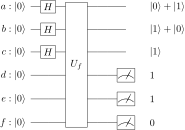

In [50]:
def preview():
    """Render TEX_FILE's current contents and display it, or show the latex/dvisvgm error.

    Also prints any warning lines from the latex/dvisvgm logs, even on a
    successful render, so problems like overfull boxes or missing glyphs
    aren't silently swallowed.
    """
    clear_output(wait=True)
    try:
        svg_bytes, log = render_svg(TEX_FILE.read_text(), capture_log=True)
    except RuntimeError as e:
        print(e)
        return

    warnings = [line for line in log.splitlines() if "warning" in line.lower()]
    if warnings:
        print("\n".join(warnings))
        print()

    display(SVG(svg_bytes))

preview()